In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FD001 raw data

→ RUL label

→ early fault label

→ sliding windows

→ centralized 1D-CNN

→ RUL + early fault results

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/TASK-ERAU/C-MAPSS"
FD = "FD001"
DATA_DIR = f"{BASE_DIR}/{FD}"

train_path = f"{DATA_DIR}/train_{FD}.txt"
test_path  = f"{DATA_DIR}/test_{FD}.txt"
rul_path   = f"{DATA_DIR}/RUL_{FD}.txt"

print("Train exists:", os.path.exists(train_path))
print("Test exists:", os.path.exists(test_path))
print("RUL exists:", os.path.exists(rul_path))

columns = (
    ["unit", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"s{i}" for i in range(1, 22)]
)

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=columns)
test_df  = pd.read_csv(test_path, sep=r"\s+", header=None, names=columns)
rul_df   = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

display(train_df.head())

Train exists: True
Test exists: True
RUL exists: True
Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


,unit,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Add RUL and early fault labels

In [3]:
FAULT_THRESHOLD = 30
RUL_CAP = 125

# Training RUL
train_df["max_cycle"] = train_df.groupby("unit")["cycle"].transform("max")
train_df["RUL_raw"] = train_df["max_cycle"] - train_df["cycle"]
train_df["RUL"] = train_df["RUL_raw"].clip(upper=RUL_CAP)

# Training early fault label
train_df["early_fault"] = (train_df["RUL_raw"] <= FAULT_THRESHOLD).astype(int)

display(train_df[["unit", "cycle", "max_cycle", "RUL_raw", "RUL", "early_fault"]].head())
display(train_df[["unit", "cycle", "max_cycle", "RUL_raw", "RUL", "early_fault"]].tail())

print("Train RUL summary:")
print(train_df["RUL"].describe())

print("\nEarly fault distribution:")
print(train_df["early_fault"].value_counts())
print("Early fault ratio:", train_df["early_fault"].mean())

,unit,cycle,max_cycle,RUL_raw,RUL,early_fault
0,1,1,192,191,125,0
1,1,2,192,190,125,0
2,1,3,192,189,125,0
3,1,4,192,188,125,0
4,1,5,192,187,125,0


,unit,cycle,max_cycle,RUL_raw,RUL,early_fault
20626,100,196,200,4,4,1
20627,100,197,200,3,3,1
20628,100,198,200,2,2,1
20629,100,199,200,1,1,1
20630,100,200,200,0,0,1


Train RUL summary:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

Early fault distribution:
early_fault
0    17531
1     3100
Name: count, dtype: int64
Early fault ratio: 0.15025931850128446


Add RUL labels for test data

In [4]:
# Map each test unit to its final true RUL
test_rul_map = dict(zip(range(1, len(rul_df) + 1), rul_df["RUL"].values))

test_df["max_cycle"] = test_df.groupby("unit")["cycle"].transform("max")
test_df["final_RUL"] = test_df["unit"].map(test_rul_map)

# RUL at each test cycle
test_df["RUL_raw"] = test_df["final_RUL"] + (test_df["max_cycle"] - test_df["cycle"])
test_df["RUL"] = test_df["RUL_raw"].clip(upper=RUL_CAP)

# Test early fault label
test_df["early_fault"] = (test_df["RUL_raw"] <= FAULT_THRESHOLD).astype(int)

display(test_df[["unit", "cycle", "max_cycle", "final_RUL", "RUL_raw", "RUL", "early_fault"]].head())

,unit,cycle,max_cycle,final_RUL,RUL_raw,RUL,early_fault
0,1,1,31,112,142,125,0
1,1,2,31,112,141,125,0
2,1,3,31,112,140,125,0
3,1,4,31,112,139,125,0
4,1,5,31,112,138,125,0


Split train/validation by engine ID

In [5]:
from sklearn.model_selection import train_test_split

all_units = train_df["unit"].unique()

train_units, val_units = train_test_split(
    all_units,
    test_size=0.2,
    random_state=42
)

train_part = train_df[train_df["unit"].isin(train_units)].copy()
val_part   = train_df[train_df["unit"].isin(val_units)].copy()

print("Training engines:", len(train_units))
print("Validation engines:", len(val_units))
print("Train rows:", train_part.shape)
print("Val rows:", val_part.shape)

Training engines: 80
Validation engines: 20
Train rows: (16561, 30)
Val rows: (4070, 30)


Normalize features

In [8]:
from sklearn.preprocessing import StandardScaler

feature_cols = ["setting_1", "setting_2", "setting_3"] + [f"s{i}" for i in range(1, 22)]

scaler = StandardScaler()

# Fit only on training engines
train_part[feature_cols] = scaler.fit_transform(train_part[feature_cols])

# Transform validation and test using same scaler
val_part[feature_cols] = scaler.transform(val_part[feature_cols])
test_scaled = test_df.copy()
test_scaled[feature_cols] = scaler.transform(test_scaled[feature_cols])

print("Number of input features:", len(feature_cols))

Number of input features: 24


Create sliding windows

In [9]:
WINDOW_SIZE = 30

def create_sliding_windows(df, feature_cols, window_size=30):
    X = []
    y_rul = []
    y_fault = []
    unit_ids = []
    end_cycles = []

    for unit in sorted(df["unit"].unique()):
        unit_df = df[df["unit"] == unit].sort_values("cycle").reset_index(drop=True)

        features = unit_df[feature_cols].values
        rul_values = unit_df["RUL"].values
        fault_values = unit_df["early_fault"].values
        cycles = unit_df["cycle"].values

        if len(unit_df) < window_size:
            continue

        for start in range(0, len(unit_df) - window_size + 1):
            end = start + window_size

            X.append(features[start:end])
            y_rul.append(rul_values[end - 1])
            y_fault.append(fault_values[end - 1])
            unit_ids.append(unit)
            end_cycles.append(cycles[end - 1])

    return (
        np.array(X, dtype=np.float32),
        np.array(y_rul, dtype=np.float32),
        np.array(y_fault, dtype=np.float32),
        np.array(unit_ids),
        np.array(end_cycles)
    )

X_train, y_rul_train, y_fault_train, train_window_units, train_end_cycles = create_sliding_windows(
    train_part, feature_cols, WINDOW_SIZE
)

X_val, y_rul_val, y_fault_val, val_window_units, val_end_cycles = create_sliding_windows(
    val_part, feature_cols, WINDOW_SIZE
)

X_test, y_rul_test, y_fault_test, test_window_units, test_end_cycles = create_sliding_windows(
    test_scaled, feature_cols, WINDOW_SIZE
)

print("X_train:", X_train.shape)
print("y_rul_train:", y_rul_train.shape)
print("y_fault_train:", y_fault_train.shape)

print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (14241, 30, 24)
y_rul_train: (14241,)
y_fault_train: (14241,)
X_val: (3490, 30, 24)
X_test: (10196, 30, 24)


Scale RUL target

In [10]:
y_rul_train_scaled = y_rul_train / RUL_CAP
y_rul_val_scaled   = y_rul_val / RUL_CAP
y_rul_test_scaled  = y_rul_test / RUL_CAP

print("Scaled RUL range:", y_rul_train_scaled.min(), y_rul_train_scaled.max())

Scaled RUL range: 0.0 1.0


1D-CNN multi-task model

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

input_shape = (WINDOW_SIZE, len(feature_cols))

inputs = layers.Input(shape=input_shape)

x = layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(pool_size=2)(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

rul_output = layers.Dense(1, activation="linear", name="rul_output")(x)
fault_output = layers.Dense(1, activation="sigmoid", name="fault_output")(x)

model = models.Model(inputs=inputs, outputs=[rul_output, fault_output])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={
        "rul_output": "mse",
        "fault_output": "binary_crossentropy"
    },
    loss_weights={
        "rul_output": 1.0,
        "fault_output": 0.5
    },
    metrics={
        "rul_output": ["mae"],
        "fault_output": [
            "accuracy",
            tf.keras.metrics.AUC(curve="PR", name="auprc")
        ]
    }
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 24)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      7,744 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 15, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 64)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 15, 128)   │     24,704 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 7, 128)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 128)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 7, 128)    │     49,280 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 128)    │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         65 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fault_output        │ (None, 1)         │         65 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 91,394 (357.01 KB)

 Trainable params: 90,754 (354.51 KB)

 Non-trainable params: 640 (2.50 KB)

Train the model

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
]

history = model.fit(
    X_train,
    {
        "rul_output": y_rul_train_scaled,
        "fault_output": y_fault_train
    },
    validation_data=(
        X_val,
        {
            "rul_output": y_rul_val_scaled,
            "fault_output": y_fault_val
        }
    ),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - fault_output_accuracy: 0.9743 - fault_output_auprc: 0.9796 - fault_output_loss: 0.0643 - loss: 0.0541 - rul_output_loss: 0.0219 - rul_output_mae: 0.1149 - val_fault_output_accuracy: 0.9456 - val_fault_output_auprc: 0.9489 - val_fault_output_loss: 0.1420 - val_loss: 0.0866 - val_rul_output_loss: 0.0182 - val_rul_output_mae: 0.1020 - learning_rate: 2.5000e-04
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - fault_output_accuracy: 0.9756 - fault_output_auprc: 0.9841 - fault_output_loss: 0.0577 - loss: 0.0490 - rul_output_loss: 0.0201 - rul_output_mae: 0.1097 - val_fault_output_accuracy: 0.9447 - val_fault_output_auprc: 0.9485 - val_fault_output_loss: 0.1490 - val_loss: 0.0936 - val_rul_output_loss: 0.0214 - val_rul_output_mae: 0.1102 - learning_rate: 2.5000e-04
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - fault_output_accuracy: 0.9788 - fault_output_auprc: 0.9847 - fault_output_loss: 0.0544 - loss: 0.0458 - rul_output_

Plot training curves

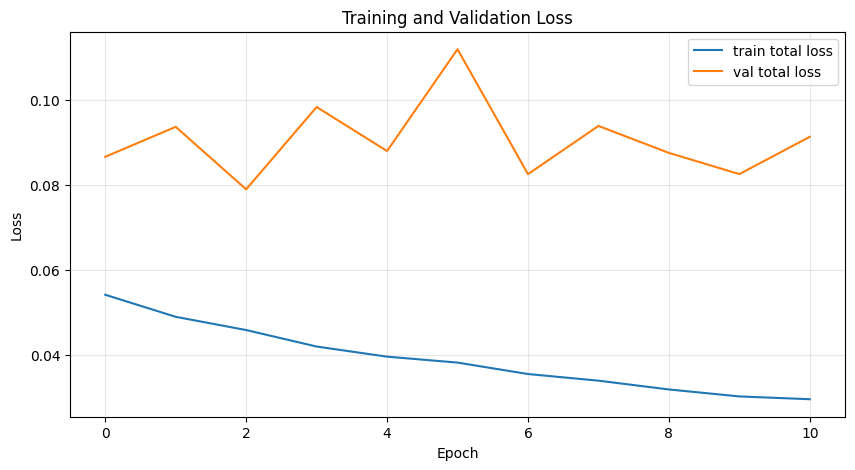

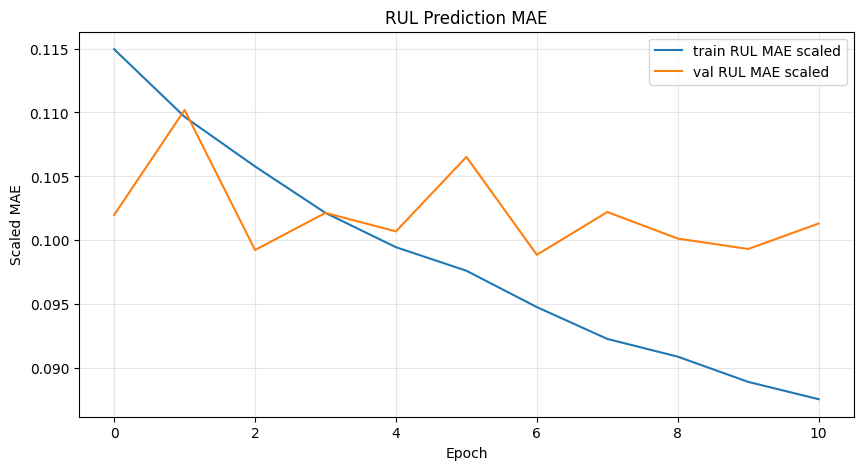

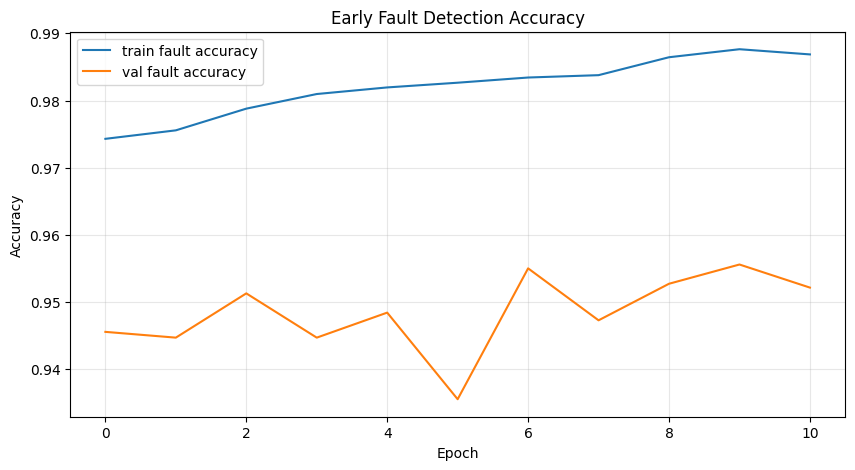

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train total loss")
plt.plot(history.history["val_loss"], label="val total loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["rul_output_mae"], label="train RUL MAE scaled")
plt.plot(history.history["val_rul_output_mae"], label="val RUL MAE scaled")
plt.xlabel("Epoch")
plt.ylabel("Scaled MAE")
plt.title("RUL Prediction MAE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["fault_output_accuracy"], label="train fault accuracy")
plt.plot(history.history["val_fault_output_accuracy"], label="val fault accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Early Fault Detection Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Evaluate on test windows

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score
)

pred_rul_scaled, pred_fault_prob = model.predict(X_test)

pred_rul = pred_rul_scaled.flatten() * RUL_CAP
pred_fault_prob = pred_fault_prob.flatten()
pred_fault = (pred_fault_prob >= 0.5).astype(int)

mae = mean_absolute_error(y_rul_test, pred_rul)
rmse = np.sqrt(mean_squared_error(y_rul_test, pred_rul))
r2 = r2_score(y_rul_test, pred_rul)

acc = accuracy_score(y_fault_test, pred_fault)
prec = precision_score(y_fault_test, pred_fault, zero_division=0)
rec = recall_score(y_fault_test, pred_fault, zero_division=0)
f1 = f1_score(y_fault_test, pred_fault, zero_division=0)
auprc = average_precision_score(y_fault_test, pred_fault_prob)

try:
    auroc = roc_auc_score(y_fault_test, pred_fault_prob)
except:
    auroc = None

print("===== Test Results: All Test Windows =====")
print(f"RUL MAE:  {mae:.4f}")
print(f"RUL RMSE: {rmse:.4f}")
print(f"RUL R2:   {r2:.4f}")

print(f"Fault Accuracy:  {acc:.4f}")
print(f"Fault Precision: {prec:.4f}")
print(f"Fault Recall:    {rec:.4f}")
print(f"Fault F1:        {f1:.4f}")
print(f"Fault AUPRC:     {auprc:.4f}")
print(f"Fault AUROC:     {auroc}")

319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
===== Test Results: All Test Windows =====
RUL MAE:  13.0766
RUL RMSE: 17.7958
RUL R2:   0.6416
Fault Accuracy:  0.9807
Fault Precision: 0.8027
Fault Recall:    0.5392
Fault F1:        0.6450
Fault AUPRC:     0.7921
Fault AUROC:     0.9891796504753808


Evaluate only final window per test engine

In [20]:
test_window_info = pd.DataFrame({
    "idx": np.arange(len(test_window_units)),
    "unit": test_window_units,
    "end_cycle": test_end_cycles
})

last_window_indices = (
    test_window_info
    .sort_values("end_cycle")
    .groupby("unit")["idx"]
    .last()
    .values
)

X_test_last = X_test[last_window_indices]
y_rul_test_last = y_rul_test[last_window_indices]
y_fault_test_last = y_fault_test[last_window_indices]

pred_rul_scaled_last, pred_fault_prob_last = model.predict(X_test_last)

pred_rul_last = pred_rul_scaled_last.flatten() * RUL_CAP
pred_fault_prob_last = pred_fault_prob_last.flatten()
pred_fault_last = (pred_fault_prob_last >= 0.5).astype(int)

mae_last = mean_absolute_error(y_rul_test_last, pred_rul_last)
rmse_last = np.sqrt(mean_squared_error(y_rul_test_last, pred_rul_last))
r2_last = r2_score(y_rul_test_last, pred_rul_last)

acc_last = accuracy_score(y_fault_test_last, pred_fault_last)
prec_last = precision_score(y_fault_test_last, pred_fault_last, zero_division=0)
rec_last = recall_score(y_fault_test_last, pred_fault_last, zero_division=0)
f1_last = f1_score(y_fault_test_last, pred_fault_last, zero_division=0)
auprc_last = average_precision_score(y_fault_test_last, pred_fault_prob_last)

try:
    auroc_last = roc_auc_score(y_fault_test_last, pred_fault_prob_last)
except:
    auroc_last = None

print("===== Test Results: Final Window Per Test Engine =====")
print(f"RUL MAE:  {mae_last:.4f}")
print(f"RUL RMSE: {rmse_last:.4f}")
print(f"RUL R2:   {r2_last:.4f}")

print(f"Fault Accuracy:  {acc_last:.4f}")
print(f"Fault Precision: {prec_last:.4f}")
print(f"Fault Recall:    {rec_last:.4f}")
print(f"Fault F1:        {f1_last:.4f}")
print(f"Fault AUPRC:     {auprc_last:.4f}")
print(f"Fault AUROC:     {auroc_last}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
===== Test Results: Final Window Per Test Engine =====
RUL MAE:  15.4965
RUL RMSE: 19.9133
RUL R2:   0.7531
Fault Accuracy:  0.8800
Fault Precision: 0.9333
Fault Recall:    0.5600
Fault F1:        0.7000
Fault AUPRC:     0.9383
Fault AUROC:     0.9792


Visualize true vs predicted RUL

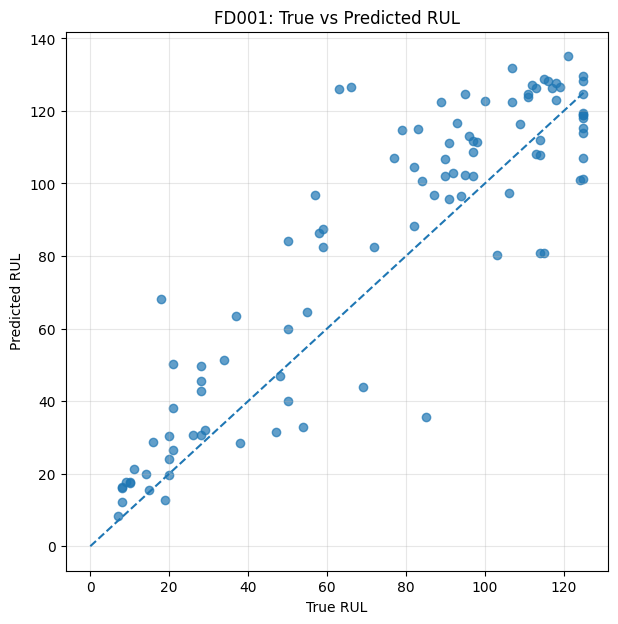

In [21]:
plt.figure(figsize=(7, 7))
plt.scatter(y_rul_test_last, pred_rul_last, alpha=0.7)
plt.plot([0, RUL_CAP], [0, RUL_CAP], linestyle="--")

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("FD001: True vs Predicted RUL")
plt.grid(True, alpha=0.3)
plt.show()

Save results

In [ ]:
results_df = pd.DataFrame({
    "unit": test_window_info.iloc[last_window_indices]["unit"].values,
    "true_RUL": y_rul_test_last,
    "pred_RUL": pred_rul_last,
    "true_fault": y_fault_test_last,
    "pred_fault_prob": pred_fault_prob_last,
    "pred_fault": pred_fault_last
})

save_path = f"{DATA_DIR}/fd001_1dcnn_predictions.csv"
results_df.to_csv(save_path, index=False)

print("Saved predictions to:", save_path)
display(results_df.head())